In [80]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg') # Removed to allow figures to display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, StackingRegressor, VotingRegressor)
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import os

OUT = '/mnt/user-data/outputs'
os.makedirs(OUT, exist_ok=True)

SEED = 42
np.random.seed(SEED)

In [81]:
# PART A
#QN.1Summary Statistics
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Read the dataset
df = pd.read_csv("/content/drive/MyDrive/Refactory/REFACTORY/paddydataset.csv")
df.columns = df.columns.str.strip()

TARGET = 'Paddy yield(in Kg)'
# Display first 5 rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [82]:
# --- Consolidated input-intensity ratios (per Hectare) ---
# Instead of raw totals (which are just Hectares × rate), we compute
# *how much was applied per unit area*. This lets the model learn
# over-application, under-application and the optimal band.
input_cols = {
    'Seedrate(in Kg)':          'seed_rate_per_ha',
    'DAP_20days':               'dap_per_ha',
    'Urea_40Days':              'urea_per_ha',
    'Potassh_50Days':           'potash_per_ha',
    'Micronutrients_70Days':    'micro_per_ha',
    'Pest_60Day(in ml)':        'pest_per_ha',
    'LP_Mainfield(in Tonnes)':  'lp_main_per_ha',
    'LP_nurseryarea(in Tonnes)':'lp_nursery_per_ha',
    'Weed28D_thiobencarb':      'weed_per_ha',
}
for raw, new in input_cols.items():
    df[new] = df[raw] / df['Hectares']

In [83]:
# Composite intensity score: mean of all z-scored ratios
ratio_cols = list(input_cols.values())
z = (df[ratio_cols] - df[ratio_cols].mean()) / df[ratio_cols].std()
df['composite_intensity'] = z.mean(axis=1)


In [84]:
# Yield per hectare (target normalised by scale for EDA insights)
df['yield_per_ha'] = df[TARGET] / df['Hectares']

In [85]:
# --- Climate aggregate features (time-series proxy) ---
# The dataset has 4 growth-window columns for Rain, Temp, Humidity.
# We create mean and range across windows to capture season-level effects.
rain_cols   = ['30DRain( in mm)', '30_50DRain( in mm)', '51_70DRain(in mm)', '71_105DRain(in mm)']
tmin_cols   = ['Min temp_D1_D30','Min temp_D31_D60','Min temp_D61_D90','Min temp_D91_D120']
tmax_cols   = ['Max temp_D1_D30','Max temp_D31_D60','Max temp_D61_D90','Max temp_D91_D120']
rh_cols     = ['Relative Humidity_D1_D30','Relative Humidity_D31_D60',
               'Relative Humidity_D61_D90','Relative Humidity_D91_D120']

df['mean_rain']       = df[rain_cols].mean(axis=1)
df['total_rain']      = df[rain_cols].sum(axis=1)
df['rain_cv']         = df[rain_cols].std(axis=1) / (df[rain_cols].mean(axis=1) + 1)  # variability
df['mean_tmin']       = df[tmin_cols].mean(axis=1)
df['mean_tmax']       = df[tmax_cols].mean(axis=1)
df['temp_range']      = df['mean_tmax'] - df['mean_tmin']
df['mean_rh']         = df[rh_cols].mean(axis=1)
df['rh_range']        = df[rh_cols].max(axis=1) - df[rh_cols].min(axis=1)

In [86]:
# --- Encode categoricals ---
cat_cols = ['Agriblock','Variety','Soil Types','Nursery']
le_map = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c].astype(str))
    le_map[c] = le

print("Dataset shape:", df.shape)
print("Target stats:\n", df[TARGET].describe().round(1))


Dataset shape: (2789, 68)
Target stats:
 count     2789.0
mean     22517.7
std       9199.7
min       5410.0
25%      16389.0
50%      24636.0
75%      31035.0
max      38814.0
Name: Paddy yield(in Kg), dtype: float64


# 2. EDA VISUALISATIONS

In [87]:

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

PALETTE = ['#378ADD','#1D9E75','#EF9F27','#E24B4A','#7F77DD','#D85A30']

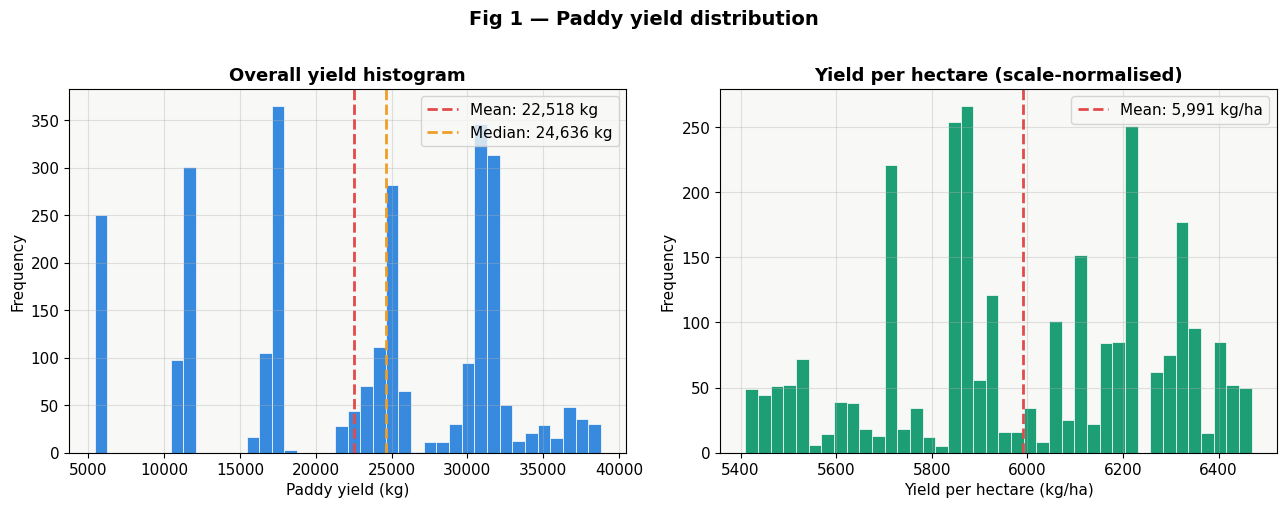

Saved fig1


In [88]:
# ── Plot 1: Target distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fig 1 — Paddy yield distribution', fontsize=14, fontweight='bold', y=1.01)

axes[0].hist(df[TARGET], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].axvline(df[TARGET].mean(), color='#E24B4A', lw=2, linestyle='--', label=f'Mean: {df[TARGET].mean():,.0f} kg')
axes[0].axvline(df[TARGET].median(), color='#EF9F27', lw=2, linestyle='--', label=f'Median: {df[TARGET].median():,.0f} kg')
axes[0].set_xlabel('Paddy yield (kg)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall yield histogram')
axes[0].legend()

axes[1].hist(df['yield_per_ha'], bins=40, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['yield_per_ha'].mean(), color='#E24B4A', lw=2, linestyle='--',
                label=f'Mean: {df["yield_per_ha"].mean():,.0f} kg/ha')
axes[1].set_xlabel('Yield per hectare (kg/ha)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Yield per hectare (scale-normalised)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUT}/fig1_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig1")

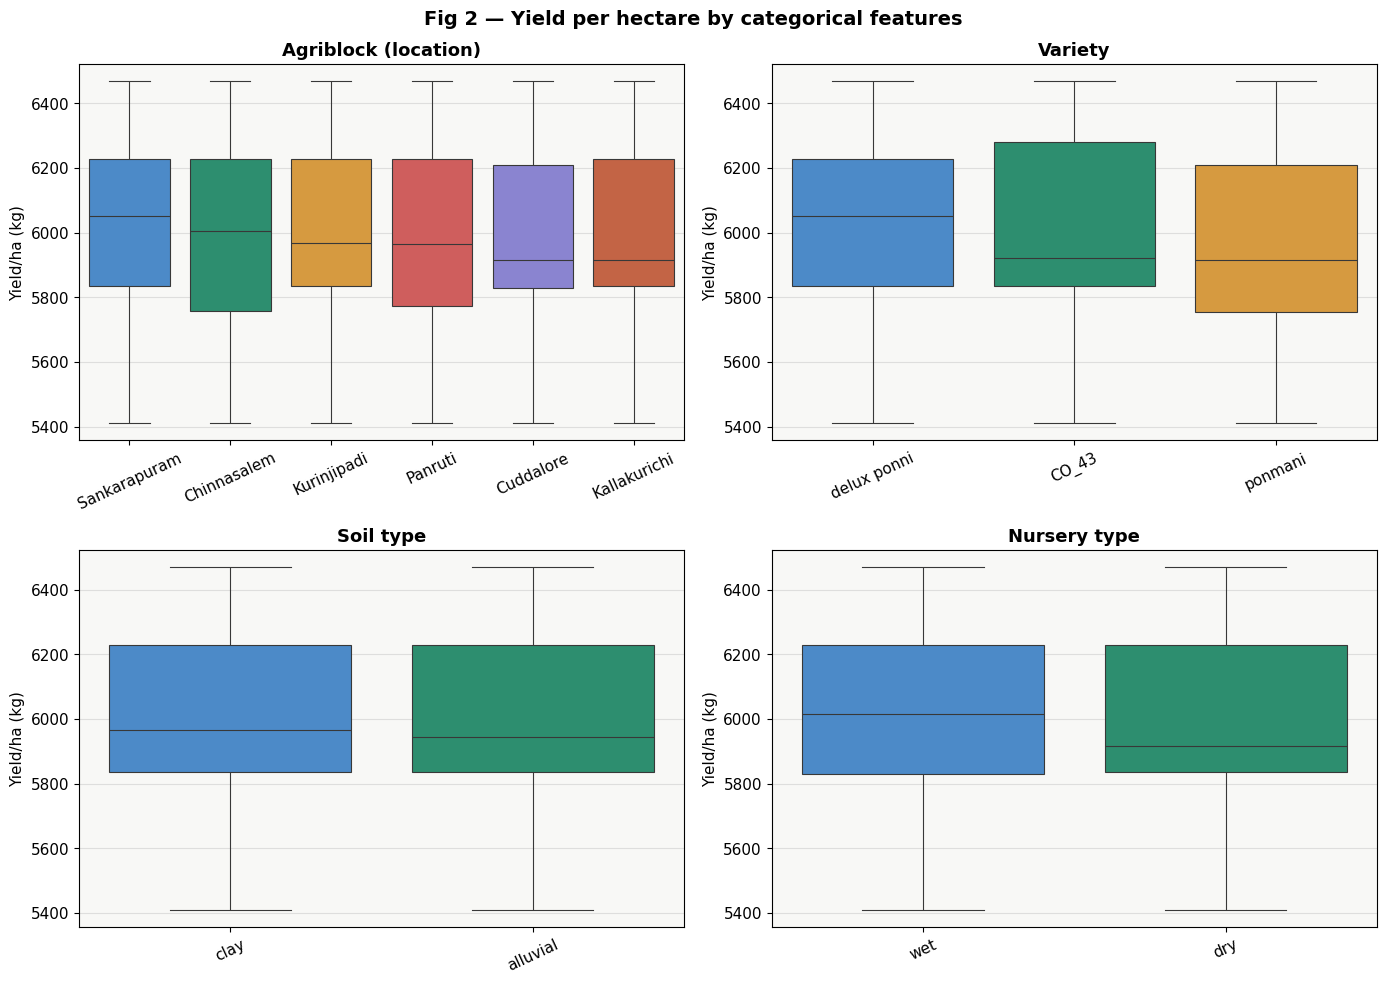

Saved fig2


In [89]:
# ── Plot 2: Yield by categorical variables ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fig 2 — Yield per hectare by categorical features', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes.flatten(), cat_cols,
    ['Agriblock (location)', 'Variety', 'Soil type', 'Nursery type']):
    order = df.groupby(col)['yield_per_ha'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='yield_per_ha', order=order, ax=ax,
                palette=PALETTE[:len(df[col].unique())], linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Yield/ha (kg)')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(f'{OUT}/fig2_yield_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig2")

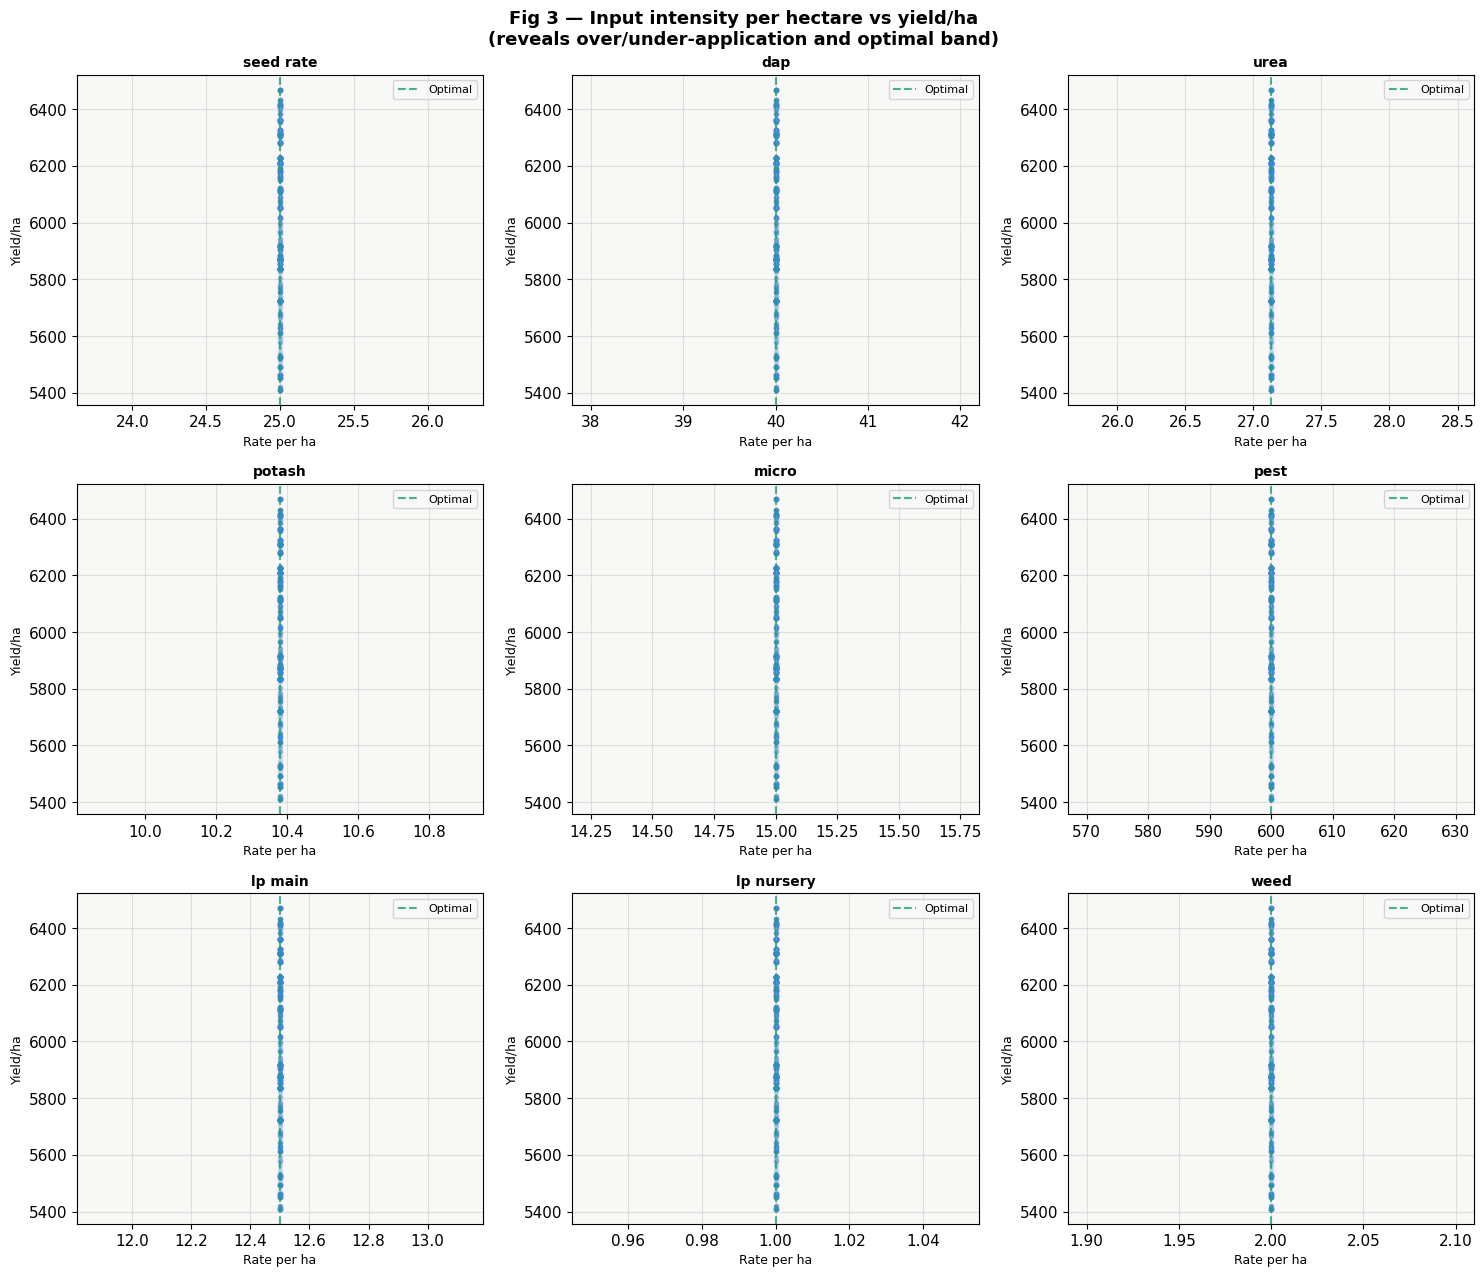

Saved fig3


In [90]:
# ── Plot 3: Input intensity vs yield per hectare ─────────────────
# This is the core consolidation concept: showing the non-linear
# (inverted-U) relationship between application rate and yield.
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle('Fig 3 — Input intensity per hectare vs yield/ha\n(reveals over/under-application and optimal band)',
             fontsize=13, fontweight='bold')

for ax, (raw, ratio) in zip(axes.flatten(), input_cols.items()):
    x = df[ratio]
    y = df['yield_per_ha']
    ax.scatter(x, y, alpha=0.08, s=8, color='#378ADD')
    # Polynomial trend line
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)
    xs = np.linspace(x.quantile(0.01), x.quantile(0.99), 200)
    ax.plot(xs, p(xs), color='#E24B4A', lw=2)
    # Shade optimal band (within ±0.5 SD of the peak)
    peak_x = -z[1] / (2 * z[0]) if z[0] < 0 else xs[np.argmax(p(xs))]
    ax.axvline(peak_x, color='#1D9E75', lw=1.5, linestyle='--', alpha=0.8, label='Optimal')
    ax.set_title(ratio.replace('_per_ha','').replace('_',' '), fontsize=10)
    ax.set_xlabel('Rate per ha', fontsize=9)
    ax.set_ylabel('Yield/ha', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/fig3_input_intensity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig3")

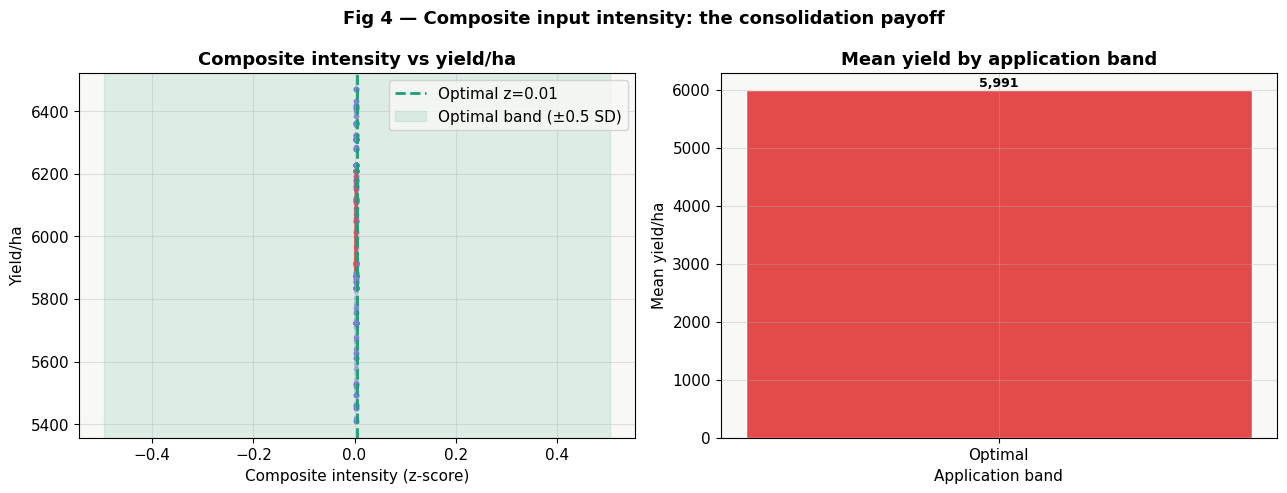

Saved fig4


In [91]:
# ── Plot 4: Composite intensity vs yield (the consolidation payoff) ─
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fig 4 — Composite input intensity: the consolidation payoff',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(df['composite_intensity'], df['yield_per_ha'], alpha=0.08, s=8, color='#7F77DD')
z = np.polyfit(df['composite_intensity'], df['yield_per_ha'], 2)
p = np.poly1d(z)
xs = np.linspace(df['composite_intensity'].quantile(0.01),
                 df['composite_intensity'].quantile(0.99), 300)
ax.plot(xs, p(xs), color='#E24B4A', lw=2.5)
peak = -z[1]/(2*z[0]) if z[0]<0 else xs[np.argmax(p(xs))]
ax.axvline(peak, color='#1D9E75', lw=2, linestyle='--', label=f'Optimal z={peak:.2f}')
ax.axvspan(peak-0.5, peak+0.5, alpha=0.12, color='#1D9E75', label='Optimal band (±0.5 SD)')
ax.set_xlabel('Composite intensity (z-score)'); ax.set_ylabel('Yield/ha')
ax.set_title('Composite intensity vs yield/ha')
ax.legend()

ax = axes[1]
bins = pd.cut(df['composite_intensity'], bins=[-4,-1.5,-0.5,0.5,1.5,4],
              labels=['Very low','Low','Optimal','High','Very high'])
grp = df.groupby(bins, observed=True)['yield_per_ha'].mean()
colors = ['#E24B4A','#EF9F27','#1D9E75','#EF9F27','#E24B4A']
bars = ax.bar(grp.index.astype(str), grp.values, color=colors, edgecolor='white')
ax.set_xlabel('Application band'); ax.set_ylabel('Mean yield/ha')
ax.set_title('Mean yield by application band')
for bar, val in zip(bars, grp.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT}/fig4_composite_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig4")

In [92]:
# ── Plot 5: Climate windows — time-series proxy ──────────────────
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Fig 5 — Climate variables across growth windows (time-series proxy)',
             fontsize=13, fontweight='bold')

windows = ['D1-D30','D31-D60','D61-D90','D91-D120']

<Figure size 1500x1000 with 0 Axes>

In [93]:
# 5a: Mean rainfall per window coloured by yield quintile
ax1 = fig.add_subplot(gs[0,0])
rain_data = df[rain_cols].values
yield_q = pd.qcut(df[TARGET], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
for q, col in zip(['Q1','Q2','Q3','Q4','Q5'], ['#E24B4A','#EF9F27','#888780','#85B7EB','#378ADD']):
    mask = yield_q == q
    means = rain_data[mask].mean(axis=0)
    ax1.plot(windows, means, marker='o', label=q, color=col, lw=2)
ax1.set_title('Rainfall per window by yield quintile')
ax1.set_xlabel('Growth window'); ax1.set_ylabel('Mean rain (mm)')
ax1.legend(title='Yield quintile', fontsize=8)

In [94]:
# 5b: Temperature range across windows
ax2 = fig.add_subplot(gs[0,1])
tmin_data = df[tmin_cols].values
tmax_data = df[tmax_cols].values
mean_tmin = tmin_data.mean(axis=0)
mean_tmax = tmax_data.mean(axis=0)
ax2.fill_between(windows, mean_tmin, mean_tmax, alpha=0.3, color='#EF9F27')
ax2.plot(windows, mean_tmin, marker='s', color='#378ADD', lw=2, label='Min temp')
ax2.plot(windows, mean_tmax, marker='^', color='#E24B4A', lw=2, label='Max temp')
ax2.set_title('Mean temperature range per window')
ax2.set_xlabel('Growth window'); ax2.set_ylabel('Temperature (°C)')
ax2.legend()

In [95]:
# 5c: Relative humidity trend
ax3 = fig.add_subplot(gs[1,0])
rh_data = df[rh_cols].values
for q, col in zip(['Q1','Q3','Q5'], ['#E24B4A','#888780','#378ADD']):
    mask = yield_q == q
    means = rh_data[mask].mean(axis=0)
    ax3.plot(windows, means, marker='o', label=f'Yield {q}', color=col, lw=2)
ax3.set_title('Humidity per window: low vs high yield')
ax3.set_xlabel('Growth window'); ax3.set_ylabel('Relative humidity (%)')
ax3.legend()

In [96]:
# 5d: Heatmap of window correlations with yield
ax4 = fig.add_subplot(gs[1,1])
window_feats = rain_cols + tmin_cols + tmax_cols + rh_cols
corr_with_yield = df[window_feats + [TARGET]].corr()[TARGET].drop(TARGET)
labels = ([f'Rain {w}' for w in windows] + [f'Tmin {w}' for w in windows] +
          [f'Tmax {w}' for w in windows] + [f'RH {w}' for w in windows])
colors = ['#378ADD' if v>0 else '#E24B4A' for v in corr_with_yield]
y_pos = range(len(corr_with_yield))
ax4.barh(y_pos, corr_with_yield.values, color=colors, edgecolor='white', height=0.7)
ax4.set_yticks(list(y_pos)); ax4.set_yticklabels(labels, fontsize=8)
ax4.axvline(0, color='black', lw=0.8)
ax4.set_title('Window feature correlation with yield')
ax4.set_xlabel('Pearson r')

plt.savefig(f'{OUT}/fig5_climate_windows.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig5")

<Figure size 640x480 with 0 Axes>

Saved fig5


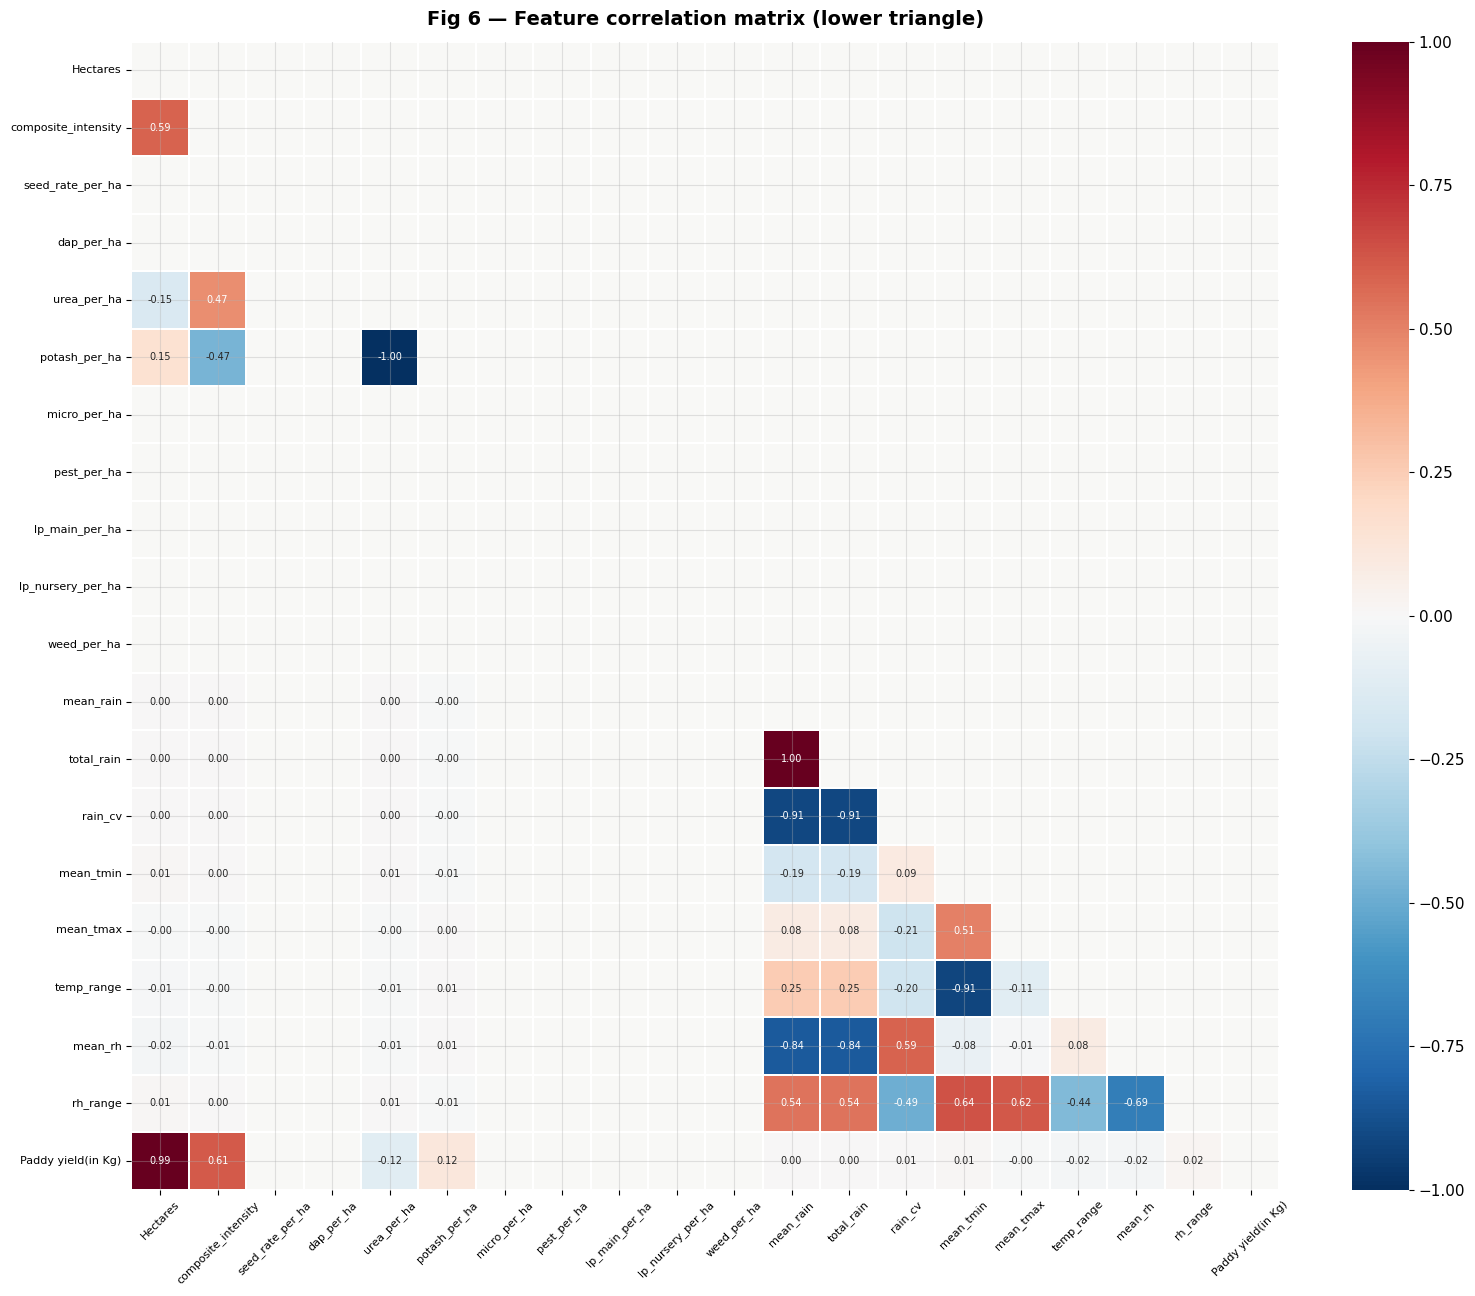

Saved fig6


In [97]:
# ── Plot 6: Correlation heatmap of final model features ──────────
final_num_features = (
    ['Hectares','composite_intensity'] +
    ratio_cols +
    ['mean_rain','total_rain','rain_cv','mean_tmin','mean_tmax','temp_range','mean_rh','rh_range'] +
    [TARGET]
)
corr_matrix = df[final_num_features].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            annot_kws={'size': 7}, square=True)
ax.set_title('Fig 6 — Feature correlation matrix (lower triangle)', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(f'{OUT}/fig6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig6")

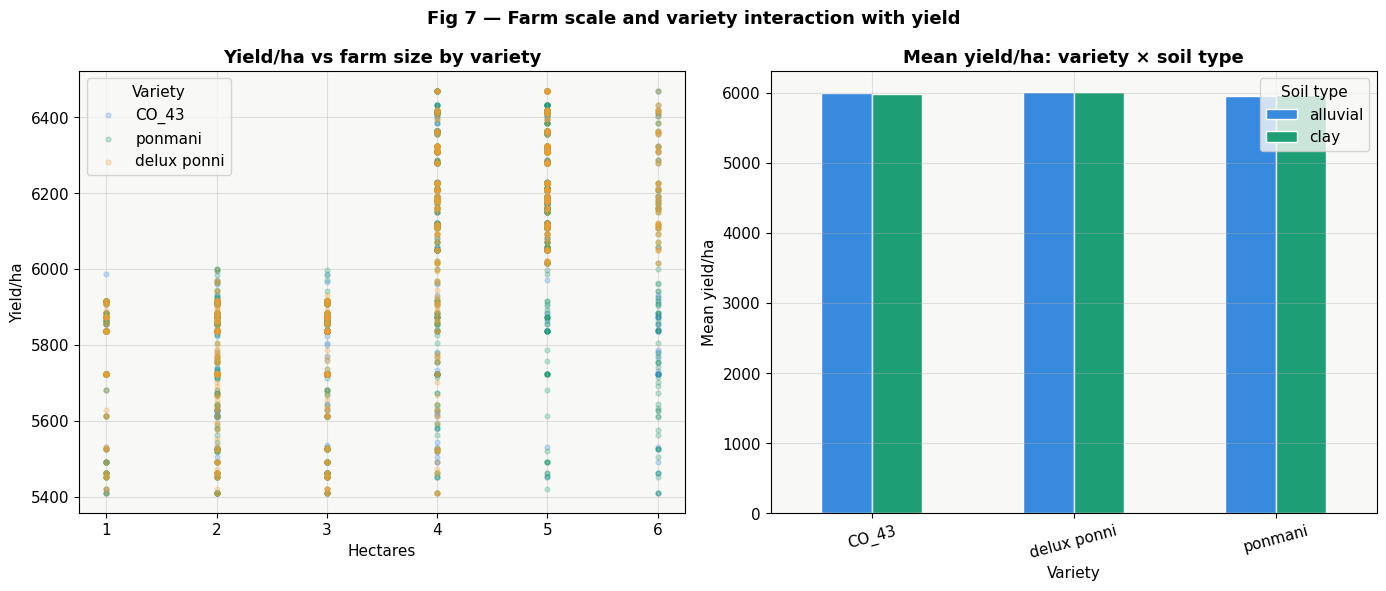

Saved fig7


In [98]:
# ── Plot 7: Yield by Hectares + Variety interaction ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fig 7 — Farm scale and variety interaction with yield', fontsize=13, fontweight='bold')

ax = axes[0]
for var, col in zip(df['Variety'].unique(), PALETTE):
    sub = df[df['Variety']==var]
    ax.scatter(sub['Hectares'], sub['yield_per_ha'], alpha=0.25, s=12,
               color=col, label=var)
ax.set_xlabel('Hectares'); ax.set_ylabel('Yield/ha')
ax.set_title('Yield/ha vs farm size by variety')
ax.legend(title='Variety')

ax = axes[1]
pivot = df.groupby(['Variety','Soil Types'])['yield_per_ha'].mean().unstack()
pivot.plot(kind='bar', ax=ax, color=PALETTE[:2], edgecolor='white')
ax.set_title('Mean yield/ha: variety × soil type')
ax.set_xlabel('Variety'); ax.set_ylabel('Mean yield/ha')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Soil type')

plt.tight_layout()
plt.savefig(f'{OUT}/fig7_interactions.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig7")

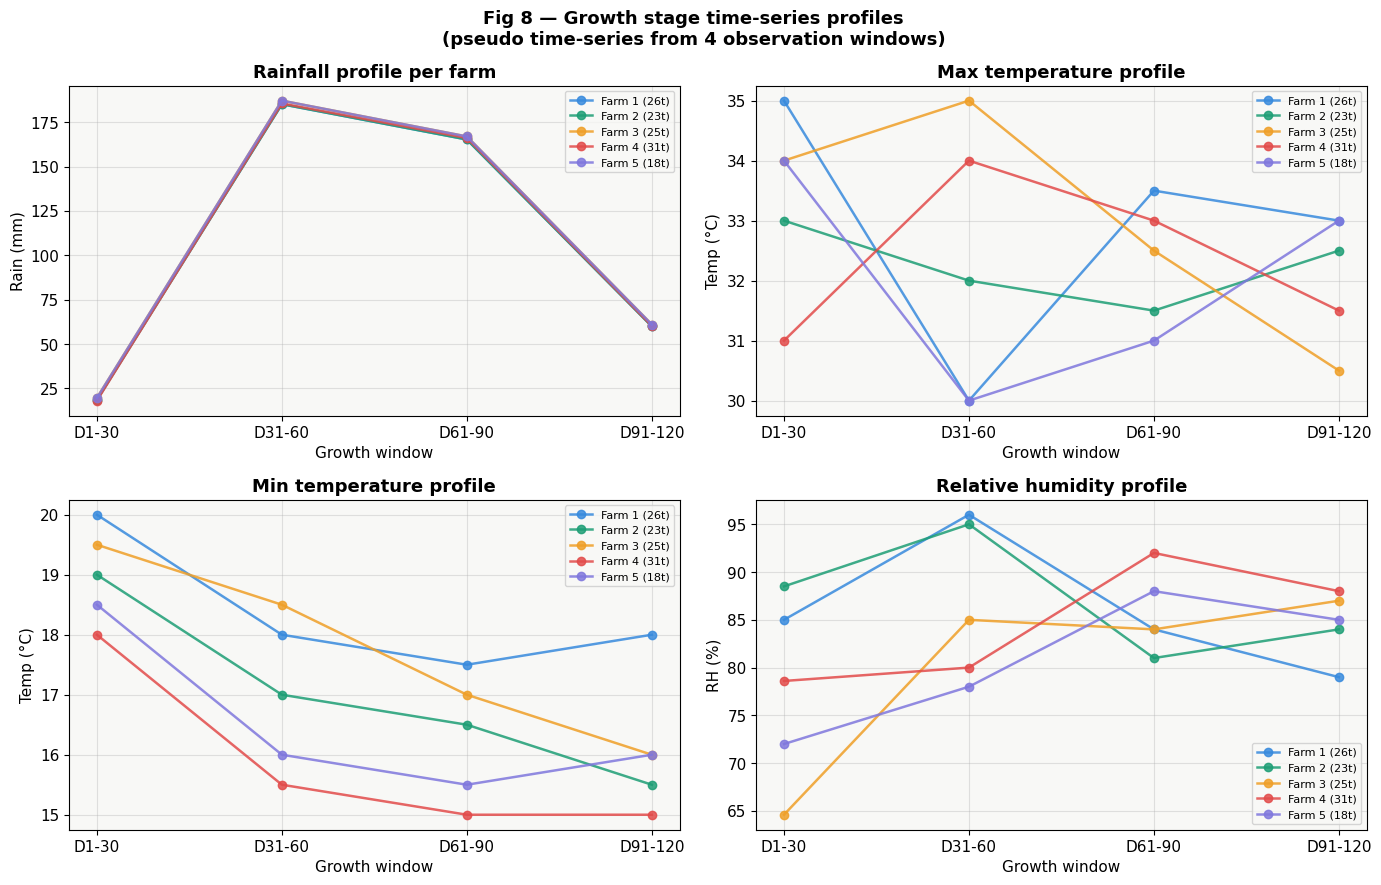

Saved fig8


In [99]:
# ── Plot 8: Growth window time-series for a sample farm ──────────
# Reconstructs a pseudo time-series from the window aggregates
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Fig 8 — Growth stage time-series profiles\n(pseudo time-series from 4 observation windows)',
             fontsize=13, fontweight='bold')

sample_idx = df.sample(5, random_state=SEED).index
window_labels = ['D1-30', 'D31-60', 'D61-90', 'D91-120']

for ax, (feat_cols, title, ylabel) in zip(axes.flatten(), [
    (rain_cols,  'Rainfall profile per farm', 'Rain (mm)'),
    (tmax_cols,  'Max temperature profile',   'Temp (°C)'),
    (tmin_cols,  'Min temperature profile',   'Temp (°C)'),
    (rh_cols,    'Relative humidity profile', 'RH (%)'),
]):
    for i, idx in enumerate(sample_idx):
        row = df.loc[idx, feat_cols].values
        yield_val = df.loc[idx, TARGET]
        ax.plot(window_labels, row, marker='o', lw=1.8, alpha=0.85,
                color=PALETTE[i], label=f'Farm {i+1} ({yield_val/1000:.0f}t)')
    ax.set_title(title); ax.set_xlabel('Growth window'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/fig8_timeseries_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig8")

In [100]:
# 3. FEATURE MATRIX ASSEMBLY
#
# Must:         Hectares, Variety, Soil Types, Nursery
# Recommended:  Agriblock, Rainfall, Temperature, Relative Humidity
# Consolidated: 9 ratio features + composite_intensity
# Time-series:  window aggregates

feature_cols = (
    ['Hectares'] +
    [c+'_enc' for c in cat_cols] +           # Must + Agriblock
    ratio_cols +                              # Consolidated ratios
    ['composite_intensity'] +
    ['mean_rain','total_rain','rain_cv'] +    # Climate aggregates
    ['mean_tmin','mean_tmax','temp_range'] +
    ['mean_rh','rh_range'] +
    rain_cols + tmin_cols + tmax_cols + rh_cols  # Raw window features
)

X = df[feature_cols].copy()
y = df[TARGET].copy()

# Normalise target by hectares for modelling; we'll back-transform
# (Alternatively predict raw kg — both are tried)
y_raw = y.values
y_per_ha = (y / df['Hectares']).values

print(f"\nFeature matrix: {X.shape}")
print("Features:", feature_cols)


Feature matrix: (2789, 39)
Features: ['Hectares', 'Agriblock_enc', 'Variety_enc', 'Soil Types_enc', 'Nursery_enc', 'seed_rate_per_ha', 'dap_per_ha', 'urea_per_ha', 'potash_per_ha', 'micro_per_ha', 'pest_per_ha', 'lp_main_per_ha', 'lp_nursery_per_ha', 'weed_per_ha', 'composite_intensity', 'mean_rain', 'total_rain', 'rain_cv', 'mean_tmin', 'mean_tmax', 'temp_range', 'mean_rh', 'rh_range', '30DRain( in mm)', '30_50DRain( in mm)', '51_70DRain(in mm)', '71_105DRain(in mm)', 'Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D1_D30', 'Max temp_D31_D60', 'Max temp_D61_D90', 'Max temp_D91_D120', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120']


In [101]:
import gradio as gr

# Calculate and store mean and std for ratio_cols from the training data for composite_intensity calculation in the Gradio app
mean_ratio_cols_df = df[ratio_cols].mean()
std_ratio_cols_df = df[ratio_cols].std()

def predict_paddy_yield(
    hectares, agriblock, variety, soil_types, nursery,
    seedrate_kg, dap_days, urea_days, potash_days, micronutrients_days, pest_ml,
    lp_main_tonnes, lp_nursery_tonnes, weed_thiobencarb,
    rain_d1_d30, rain_d31_d60, rain_d61_d90, rain_d91_d120,
    min_temp_d1_d30, min_temp_d31_d60, min_temp_d61_d90, min_temp_d91_d120,
    max_temp_d1_d30, max_temp_d31_d60, max_temp_d61_d90, max_temp_d91_d120,
    rh_d1_d30, rh_d31_d60, rh_d61_d90, rh_d91_d120
):
    # Create a dictionary for the new input
    input_data = {
        'Hectares': hectares,
        'Agriblock': agriblock,
        'Variety': variety,
        'Soil Types': soil_types,
        'Nursery': nursery,
        'Seedrate(in Kg)': seedrate_kg,
        'DAP_20days': dap_days,
        'Urea_40Days': urea_days,
        'Potassh_50Days': potash_days,
        'Micronutrients_70Days': micronutrients_days,
        'Pest_60Day(in ml)': pest_ml,
        'LP_Mainfield(in Tonnes)': lp_main_tonnes,
        'LP_nurseryarea(in Tonnes)': lp_nursery_tonnes,
        'Weed28D_thiobencarb': weed_thiobencarb,
        '30DRain( in mm)': rain_d1_d30,
        '30_50DRain( in mm)': rain_d31_d60,
        '51_70DRain(in mm)': rain_d61_d90,
        '71_105DRain(in mm)': rain_d91_d120,
        'Min temp_D1_D30': min_temp_d1_d30,
        'Min temp_D31_D60': min_temp_d31_d60,
        'Min temp_D61_D90': min_temp_d61_d90,
        'Min temp_D91_D120': min_temp_d91_d120,
        'Max temp_D1_D30': max_temp_d1_d30,
        'Max temp_D31_D60': max_temp_d31_d60,
        'Max temp_D61_D90': max_temp_d61_d90,
        'Max temp_D91_D120': max_temp_d91_d120,
        'Relative Humidity_D1_D30': rh_d1_d30,
        'Relative Humidity_D31_D60': rh_d31_d60,
        'Relative Humidity_D61_D90': rh_d61_d90,
        'Relative Humidity_D91_D120': rh_d91_d120
    }
    input_df = pd.DataFrame([input_data])

    # Calculate ratio features
    for raw, new in input_cols.items():
        input_df[new] = input_df[raw] / input_df['Hectares']

    # Calculate climate aggregate features
    rain_cols_local   = ['30DRain( in mm)', '30_50DRain( in mm)', '51_70DRain(in mm)', '71_105DRain(in mm)']
    tmin_cols_local   = ['Min temp_D1_D30','Min temp_D31_D60','Min temp_D61_D90','Min temp_D91_D120']
    tmax_cols_local   = ['Max temp_D1_D30','Max temp_D31_D60','Max temp_D61_D90','Max temp_D91_D120']
    rh_cols_local     = ['Relative Humidity_D1_D30','Relative Humidity_D31_D60',
                         'Relative Humidity_D61_D90','Relative Humidity_D91_D120']

    input_df['mean_rain']       = input_df[rain_cols_local].mean(axis=1)
    input_df['total_rain']      = input_df[rain_cols_local].sum(axis=1)
    input_df['rain_cv']         = input_df[rain_cols_local].std(axis=1) / (input_df[rain_cols_local].mean(axis=1) + 1)
    input_df['mean_tmin']       = input_df[tmin_cols_local].mean(axis=1)
    input_df['mean_tmax']       = input_df[tmax_cols_local].mean(axis=1)
    input_df['temp_range']      = input_df['mean_tmax'] - input_df['mean_tmin']
    input_df['mean_rh']         = input_df[rh_cols_local].mean(axis=1)
    input_df['rh_range']        = input_df[rh_cols_local].max(axis=1) - input_df[rh_cols_local].min(axis=1)

    # Encode categorical features
    for c in cat_cols:
        input_df[c + '_enc'] = le_map[c].transform(input_df[c].astype(str))

    # Calculate composite_intensity using stored means and stds from training data
    z_new = (input_df[ratio_cols] - mean_ratio_cols_df) / std_ratio_cols_df
    input_df['composite_intensity'] = z_new.mean(axis=1)

    # Select and order features for prediction
    final_features = input_df[feature_cols]

    # Predict using the best model
    prediction = best_result['model'].predict(final_features.values)
    return f"Predicted Paddy Yield: {prediction[0]:,.2f} kg"

In [102]:
# 4. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_raw, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (2231, 39), Test: (558, 39)


In [103]:
# 5. INDIVIDUAL ENSEMBLE BASE MODELS
#

def evaluate(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    """Fit, predict, and return a metrics dict."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    # 5-fold CV on training set
    cv   = cross_val_score(model, X_tr, y_tr, cv=5,
                           scoring='r2', n_jobs=-1).mean()
    print(f"  {name:<35} RMSE={rmse:>8,.0f}  MAE={mae:>8,.0f}  R²={r2:.4f}  CV-R²={cv:.4f}")
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'cv_r2': cv,
            'predictions': pred, 'model': model}

results = []

print("\n── Base learners ")


── Base learners 


In [104]:
# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, n_jobs=-1, random_state=SEED)
results.append(evaluate("Random Forest", rf, X_train, y_train, X_test, y_test))

  Random Forest                       RMSE=     871  MAE=     621  R²=0.9906  CV-R²=0.9917


In [105]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=5, subsample=0.8, random_state=SEED)
results.append(evaluate("Gradient Boosting", gb, X_train, y_train, X_test, y_test))

  Gradient Boosting                   RMSE=     868  MAE=     615  R²=0.9907  CV-R²=0.9918


In [106]:
# Extra Trees
et = ExtraTreesRegressor(n_estimators=300, min_samples_leaf=2,
                          n_jobs=-1, random_state=SEED)
results.append(evaluate("Extra Trees", et, X_train, y_train, X_test, y_test))

  Extra Trees                         RMSE=     891  MAE=     635  R²=0.9902  CV-R²=0.9913


In [107]:
# Ridge baseline
ridge = Ridge(alpha=1.0)
results.append(evaluate("Ridge (baseline)", ridge,
                         X_train_sc, y_train, X_test_sc, y_test))

  Ridge (baseline)                    RMSE=     909  MAE=     666  R²=0.9898  CV-R²=0.9904


In [108]:
# ── Stacking ensemble ─────────────────────────────────────────────
# Base: RF + GBT + ETR; Meta: Ridge trained on out-of-fold predictions
print("\n── Stacking ensemble ──────────────────────────────────────────")
stacking = StackingRegressor(
    estimators=[
        ('rf',  RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED)),
        ('gb',  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=SEED)),
        ('et',  ExtraTreesRegressor(n_estimators=200, n_jobs=-1, random_state=SEED)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
results.append(evaluate("Stacking (RF+GB+ET → Ridge)", stacking,
                         X_train, y_train, X_test, y_test))


── Stacking ensemble ──────────────────────────────────────────
  Stacking (RF+GB+ET → Ridge)         RMSE=     826  MAE=     586  R²=0.9916  CV-R²=0.9924


In [109]:
# ── Voting ensemble ───────────────────────────────────────────────
print("\n── Voting ensemble ────────────────────────────────────────────")
voting = VotingRegressor(estimators=[
    ('rf', RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED)),
    ('gb', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=SEED)),
    ('et', ExtraTreesRegressor(n_estimators=200, n_jobs=-1, random_state=SEED)),
], n_jobs=-1)
results.append(evaluate("Voting (RF+GB+ET)", voting,
                         X_train, y_train, X_test, y_test))


── Voting ensemble ────────────────────────────────────────────
  Voting (RF+GB+ET)                   RMSE=     855  MAE=     610  R²=0.9910  CV-R²=0.9920


In [110]:
# 6. NEURAL NETWORK (MLPRegressor)
#
print("\n── Neural Network ──────────────────────────────────────────────")
# Architecture: 3 hidden layers 256-128-64
# Activation: relu; Optimiser: adam; Regularisation: alpha=0.001
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,           # L2 regularisation
    learning_rate='adaptive',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    random_state=SEED
)
results.append(evaluate("Neural Network (MLP 256-128-64)",
                         mlp, X_train_sc, y_train, X_test_sc, y_test))


── Neural Network ──────────────────────────────────────────────
  Neural Network (MLP 256-128-64)     RMSE=     919  MAE=     657  R²=0.9896  CV-R²=0.9903


In [111]:
##Gemini - DEPLOYMENT

trained_models = {r['name']: r['model'] for r in results}

print(f"Trained models available: {list(trained_models.keys())}")

Trained models available: ['Random Forest', 'Gradient Boosting', 'Extra Trees', 'Ridge (baseline)', 'Stacking (RF+GB+ET → Ridge)', 'Voting (RF+GB+ET)', 'Neural Network (MLP 256-128-64)']



── Final comparison ───────────────────────────────────────────
                           name       rmse        mae       r2    cv_r2
    Stacking (RF+GB+ET → Ridge) 825.543919 586.398572 0.991598 0.992374
              Voting (RF+GB+ET) 855.269364 610.331195 0.990982 0.991958
              Gradient Boosting 868.329773 614.673607 0.990704 0.991832
                  Random Forest 871.153783 621.124511 0.990643 0.991696
                    Extra Trees 891.438831 634.911246 0.990203 0.991292
               Ridge (baseline) 908.796427 665.856772 0.989817 0.990443
Neural Network (MLP 256-128-64) 919.165010 656.755873 0.989584 0.990300


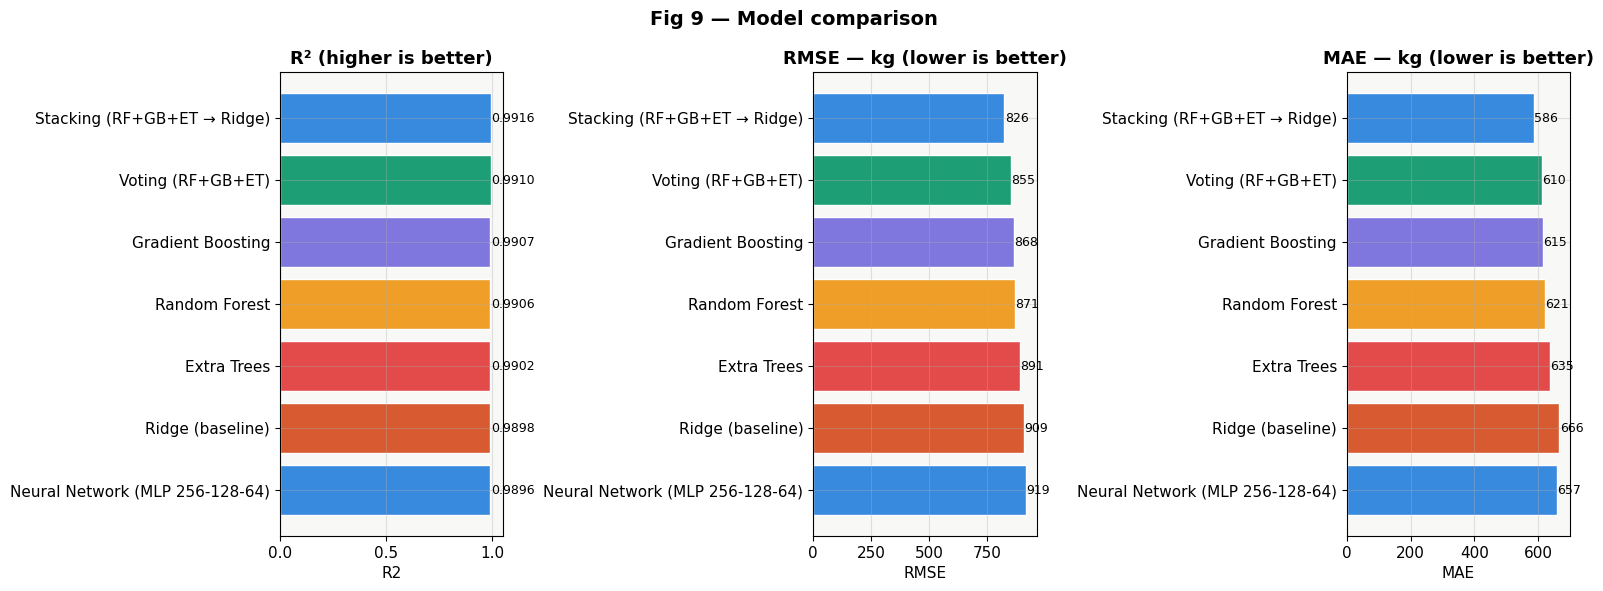

Saved fig9


In [112]:
# 7. MODEL COMPARISON PLOT
#
res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('predictions','model')}
                        for r in results])
res_df = res_df.sort_values('r2', ascending=False).reset_index(drop=True)
print("\n── Final comparison ───────────────────────────────────────────")
print(res_df[['name','rmse','mae','r2','cv_r2']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Fig 9 — Model comparison', fontsize=14, fontweight='bold')

colors_bar = ['#378ADD','#1D9E75','#7F77DD','#EF9F27','#E24B4A','#D85A30']

for ax, metric, label in zip(axes, ['r2','rmse','mae'],
    ['R² (higher is better)','RMSE — kg (lower is better)','MAE — kg (lower is better)']):
    vals = res_df[metric].values
    bars = ax.barh(res_df['name'], vals, color=colors_bar[:len(vals)], edgecolor='white')
    ax.set_title(label); ax.set_xlabel(metric.upper())
    if metric == 'r2':
        ax.set_xlim(0, 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()+0.002*max(vals), bar.get_y()+bar.get_height()/2,
                f'{v:,.0f}' if metric!='r2' else f'{v:.4f}',
                va='center', fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{OUT}/fig9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig9")

In [113]:
# Get the names of all trained models from the performance summary
all_model_names = res_df['name'].tolist()

print(f"All trained models available for comparison: {all_model_names}")

All trained models available for comparison: ['Stacking (RF+GB+ET → Ridge)', 'Voting (RF+GB+ET)', 'Gradient Boosting', 'Random Forest', 'Extra Trees', 'Ridge (baseline)', 'Neural Network (MLP 256-128-64)']


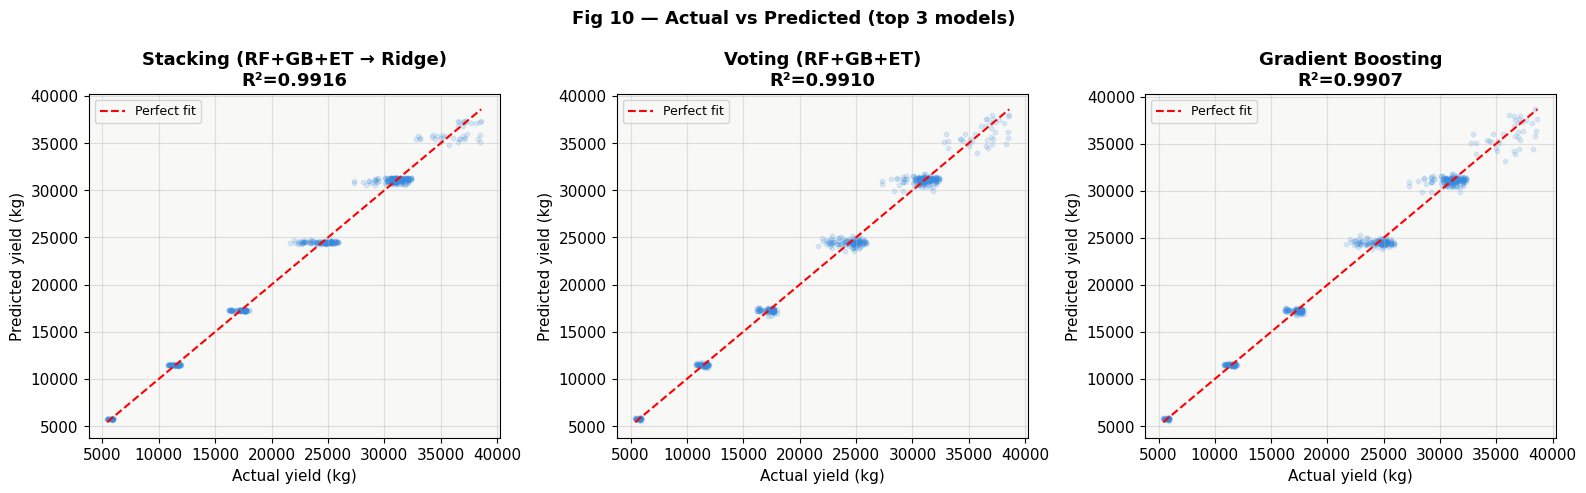

Saved fig10


In [114]:
# ── Actual vs Predicted for best 3 models ────────────────────────
top3 = res_df.head(3)['name'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 10 — Actual vs Predicted (top 3 models)', fontsize=13, fontweight='bold')

for ax, name in zip(axes, top3):
    r = next(x for x in results if x['name']==name)
    pred = r['predictions']
    ax.scatter(y_test, pred, alpha=0.15, s=10, color='#378ADD')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual yield (kg)'); ax.set_ylabel('Predicted yield (kg)')
    ax.set_title(f'{name}\nR²={r["r2"]:.4f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/fig10_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig10")

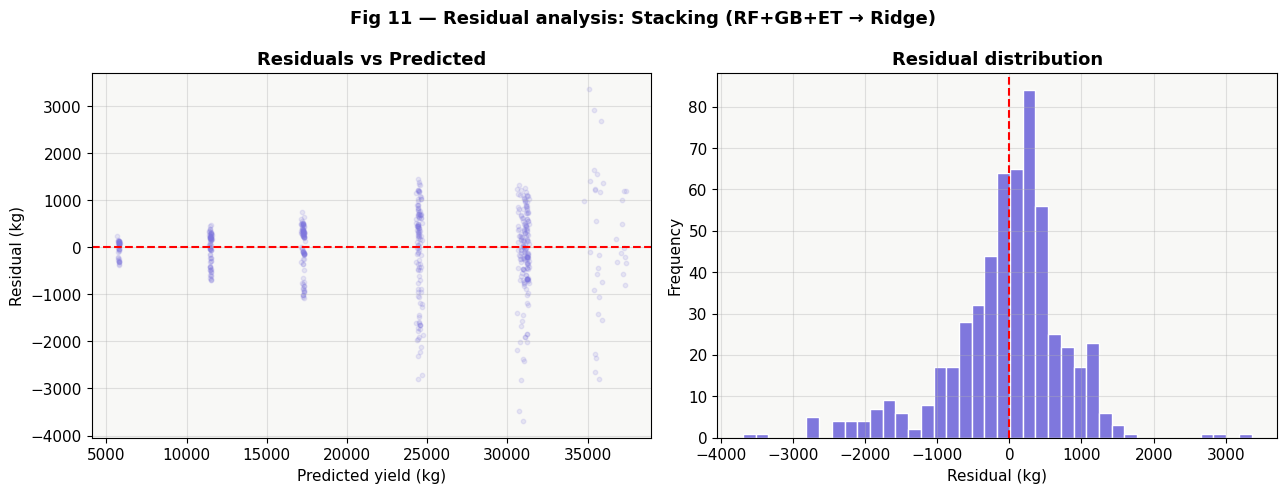

Saved fig11


In [115]:
# ── Residual plot ────────────────────────────────────────────────
best_result = next(r for r in results if r['name']==res_df.iloc[0]['name'])
residuals = y_test - best_result['predictions']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Fig 11 — Residual analysis: {res_df.iloc[0]["name"]}',
             fontsize=13, fontweight='bold')

axes[0].scatter(best_result['predictions'], residuals, alpha=0.15, s=10, color='#7F77DD')
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted yield (kg)'); axes[0].set_ylabel('Residual (kg)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=40, color='#7F77DD', edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual (kg)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.savefig(f'{OUT}/fig11_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig11")

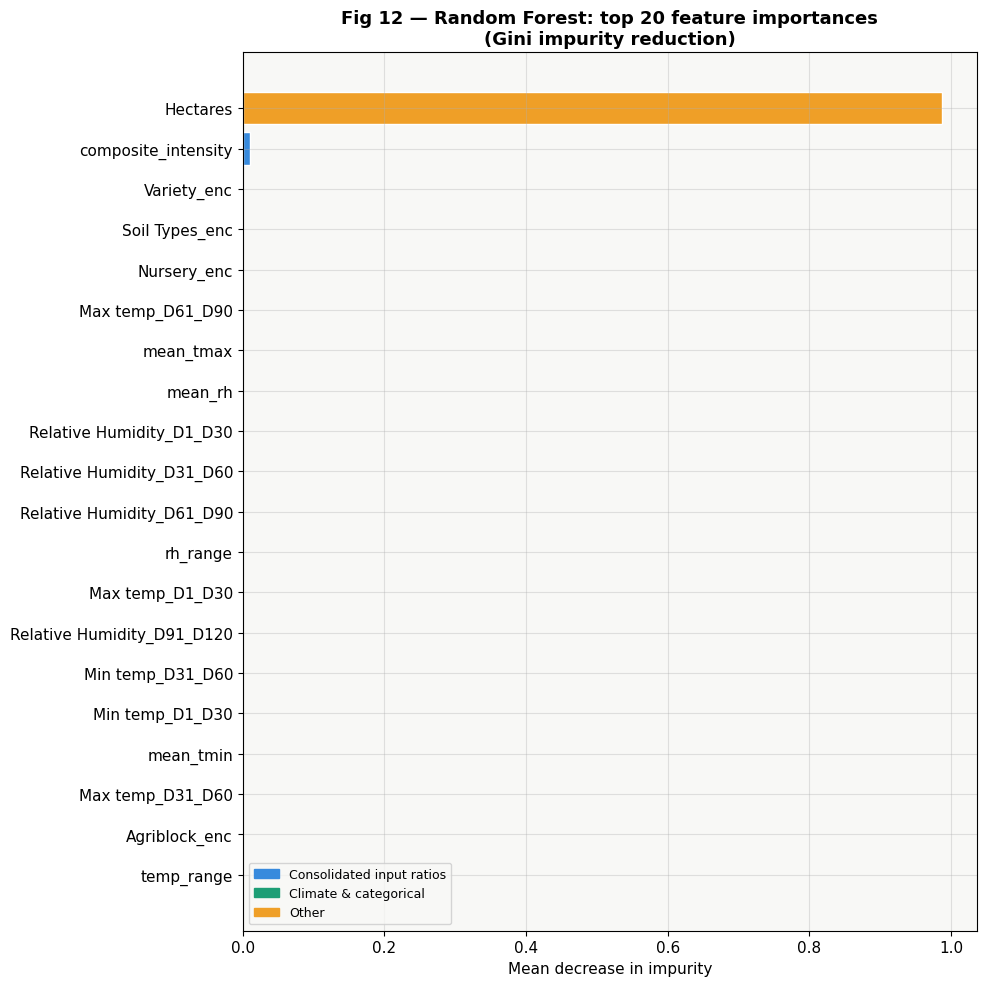

Saved fig12


In [116]:
# 8. EXPLAINABLE AI

# ── 8a: Built-in feature importances (RF) ────────────────────────
rf_model = next(r for r in results if r['name']=='Random Forest')['model']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 10))
top20 = feat_imp_df.head(20)
colors_imp = ['#378ADD' if 'per_ha' in f or 'composite' in f
              else '#1D9E75' if any(c in f for c in ['Rain','temp','rh','Humidity','_enc'])
              else '#EF9F27' for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['importance'][::-1],
        color=colors_imp[::-1], edgecolor='white')
ax.set_title('Fig 12 — Random Forest: top 20 feature importances\n(Gini impurity reduction)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean decrease in impurity')

legend_patches = [
    mpatches.Patch(color='#378ADD', label='Consolidated input ratios'),
    mpatches.Patch(color='#1D9E75', label='Climate & categorical'),
    mpatches.Patch(color='#EF9F27', label='Other'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT}/fig12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig12")


Computing permutation importance (this takes ~60s)…


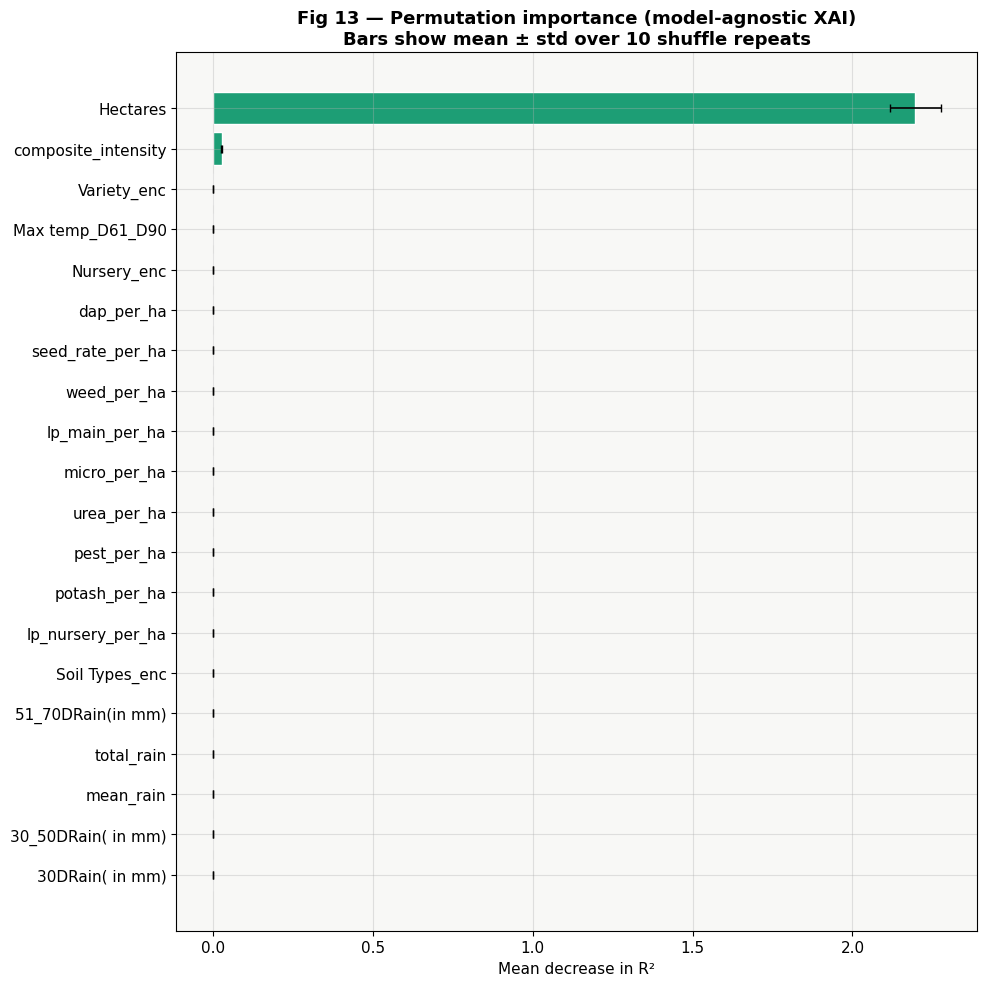

Saved fig13


In [117]:
# ── 8b: Permutation importance (model-agnostic XAI) ──────────────
# Permutation importance is more reliable than Gini importance:
# it shuffles each feature and measures how much test performance drops.
print("\nComputing permutation importance (this takes ~60s)…")
perm = permutation_importance(rf_model, X_test, y_test,
                               n_repeats=10, random_state=SEED, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std
}).sort_values('importance_mean', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
        xerr=perm_df['importance_std'][::-1], color='#1D9E75',
        edgecolor='white', error_kw={'elinewidth':1.2,'capsize':3})
ax.set_title('Fig 13 — Permutation importance (model-agnostic XAI)\nBars show mean ± std over 10 shuffle repeats',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean decrease in R²')
plt.tight_layout()
plt.savefig(f'{OUT}/fig13_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig13")

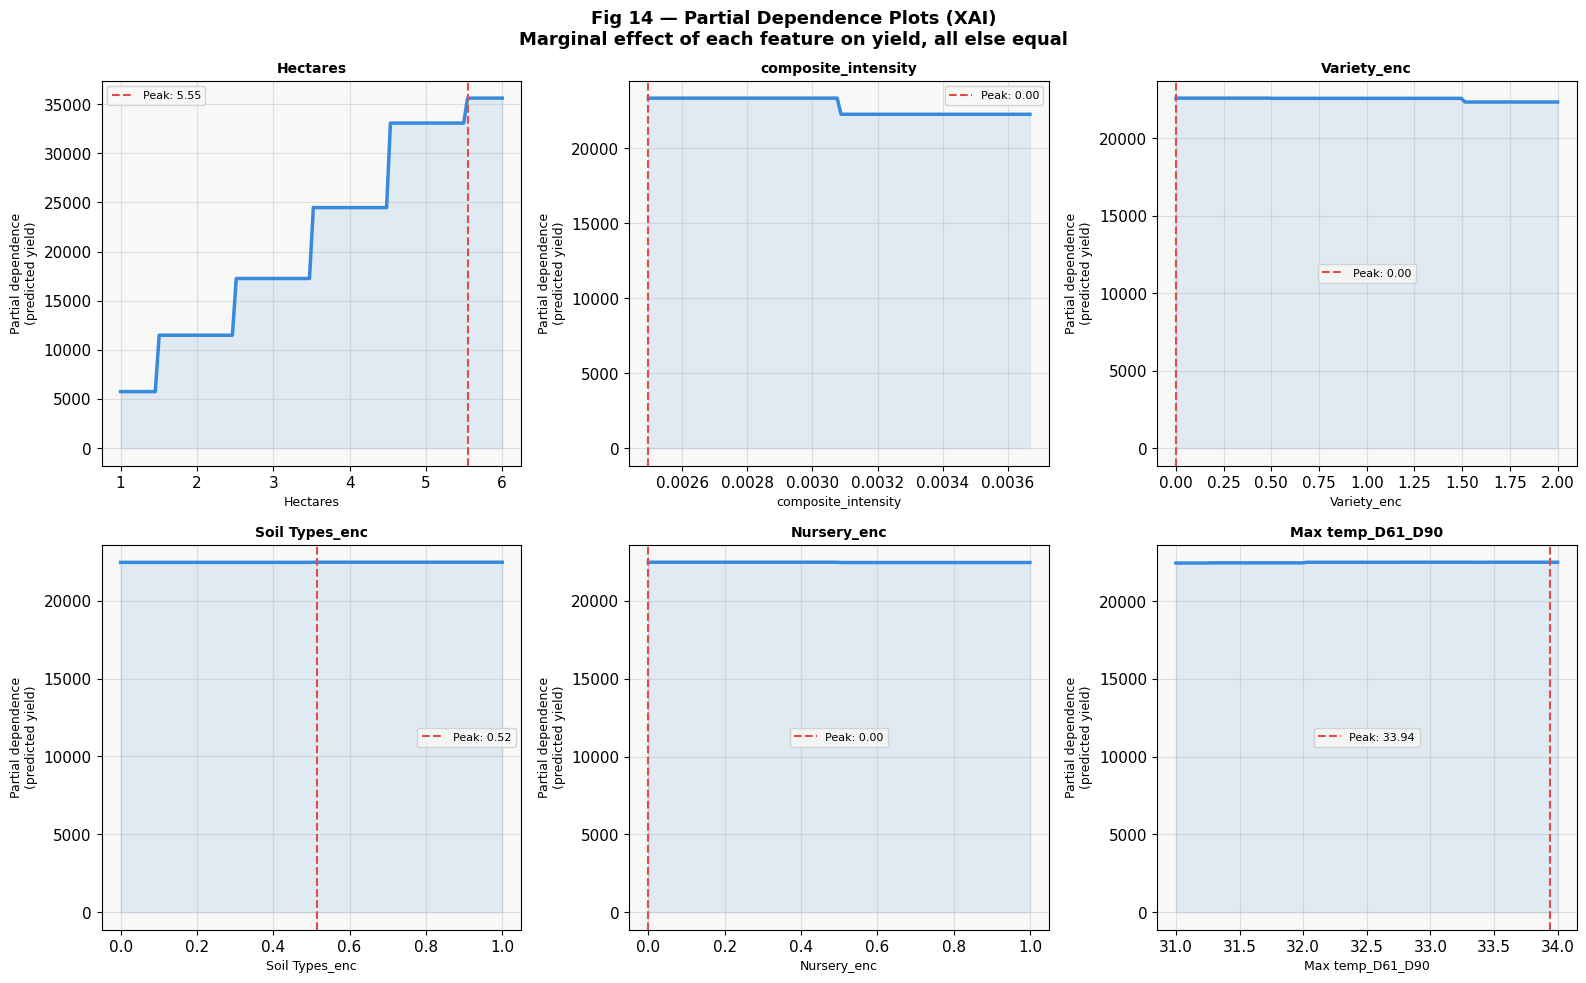

Saved fig14


In [118]:
# ── 8c: Partial Dependence Plots (PDPs) ──────────────────────────
# PDPs show the marginal effect of a single feature on predictions,
# holding all others at their mean. This directly shows over/under/optimal bands.

top_features_idx = feat_imp_df.head(6).index.tolist()
top_feature_names = feat_imp_df.head(6)['feature'].tolist()

from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Fig 14 — Partial Dependence Plots (XAI)\nMarginal effect of each feature on yield, all else equal',
             fontsize=13, fontweight='bold')

for ax, feat_name in zip(axes.flatten(), top_feature_names):
    feat_idx = feature_cols.index(feat_name)
    grid_points = np.linspace(
        np.percentile(X_train[:, feat_idx], 2),
        np.percentile(X_train[:, feat_idx], 98),
        100
    )
    # Manual PDP computation (compatible with sklearn 1.x)
    X_temp = X_train.copy()
    pd_vals = []
    for val in grid_points:
        X_temp[:, feat_idx] = val
        pd_vals.append(rf_model.predict(X_temp).mean())
    ax.plot(grid_points, pd_vals, color='#378ADD', lw=2.5)
    ax.fill_between(grid_points, pd_vals,
                    alpha=0.12, color='#378ADD')
    ax.set_title(feat_name, fontsize=10)
    ax.set_xlabel(feat_name, fontsize=9)
    ax.set_ylabel('Partial dependence\n(predicted yield)', fontsize=9)
    # Mark the optimal region (peak)
    peak_val = grid_points[np.argmax(pd_vals)]
    ax.axvline(peak_val, color='#E24B4A', lw=1.5, linestyle='--',
               label=f'Peak: {peak_val:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/fig14_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig14")

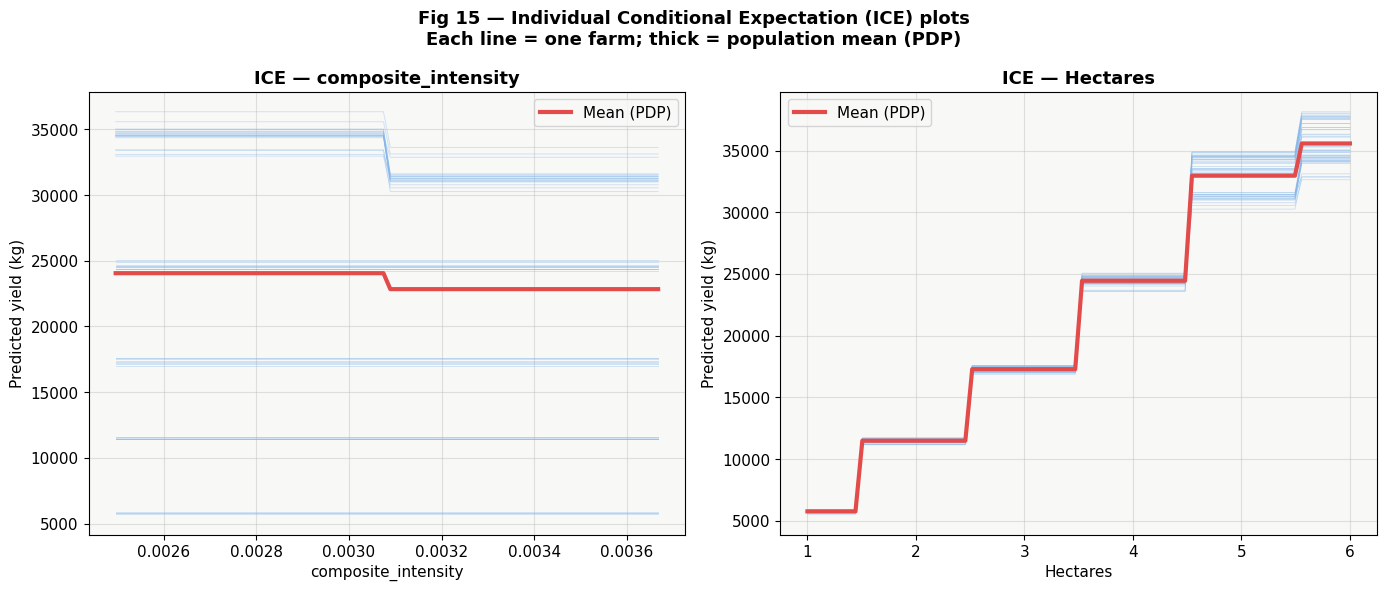

Saved fig15


In [119]:
# ── 8d: Individual prediction explanation (manual ICE) ───────────
# Individual Conditional Expectation: shows PDP for single farms
# to explain why one farm got a different prediction from another

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fig 15 — Individual Conditional Expectation (ICE) plots\n'
             'Each line = one farm; thick = population mean (PDP)',
             fontsize=13, fontweight='bold')

for ax, feat_name in zip(axes, ['composite_intensity', 'Hectares']):
    feat_idx = feature_cols.index(feat_name)
    grid_points = np.linspace(
        np.percentile(X_test[:, feat_idx], 2),
        np.percentile(X_test[:, feat_idx], 98),
        80
    )
    ice_curves = []
    sample_rows = X_test[:50]
    for row in sample_rows:
        X_ice = np.tile(row, (len(grid_points), 1))
        X_ice[:, feat_idx] = grid_points
        ice_curves.append(rf_model.predict(X_ice))
    ice_arr = np.array(ice_curves)
    for curve in ice_arr:
        ax.plot(grid_points, curve, color='#85B7EB', lw=0.6, alpha=0.4)
    ax.plot(grid_points, ice_arr.mean(axis=0), color='#E24B4A',
            lw=3, label='Mean (PDP)')
    ax.set_xlabel(feat_name); ax.set_ylabel('Predicted yield (kg)')
    ax.set_title(f'ICE — {feat_name}')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT}/fig15_ice_plots.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig15")

In [120]:
# 9. TIME-SERIES ANALYSIS: YIELD DYNAMICS ACROSS GROWTH STAGES
#
# We reconstruct a 4-point temporal sequence per farm and model
# cumulative climate impact on yield.

# Build per-farm temporal feature matrix (4 windows × climate vars)
ts_records = []
for _, row in df.iterrows():
    for i, (rn, tm_n, tx_n, rh_n) in enumerate(zip(rain_cols, tmin_cols, tmax_cols, rh_cols)):
        ts_records.append({
            'farm_id': _,
            'window': i+1,
            'rain': row[rn],
            'tmin': row[tm_n],
            'tmax': row[tx_n],
            'rh': row[rh_n],
            'yield': row[TARGET],
            'hectares': row['Hectares'],
            'variety': row['Variety'],
        })
ts_df = pd.DataFrame(ts_records)

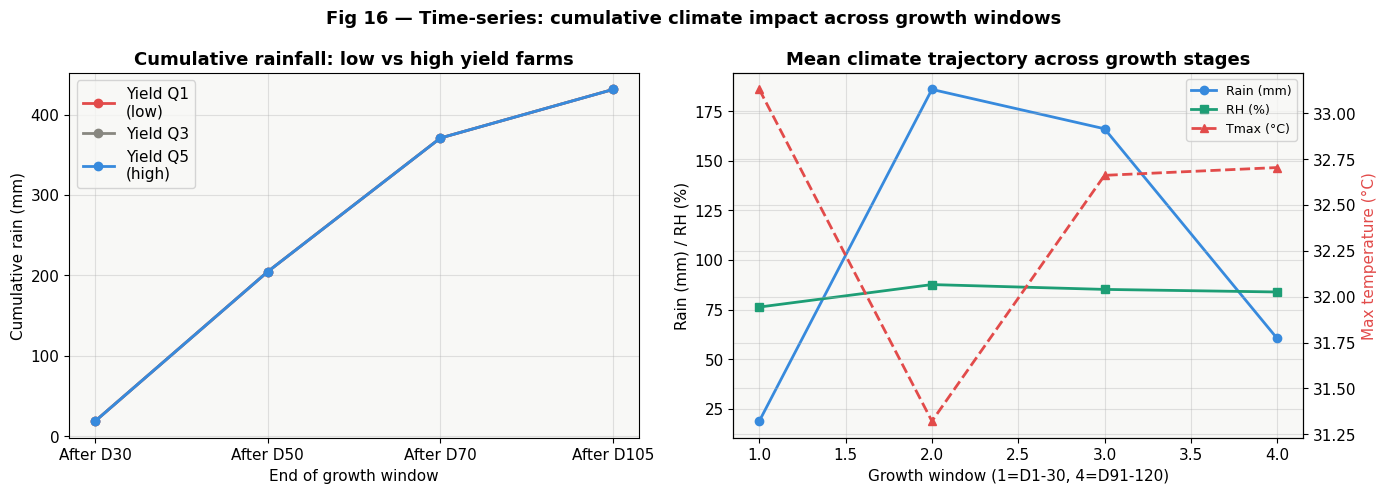

Saved fig16


In [121]:
# Cumulative rain vs yield quintile
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 16 — Time-series: cumulative climate impact across growth windows',
             fontsize=13, fontweight='bold')

ax = axes[0]
yield_q5 = pd.qcut(df[TARGET], 5, labels=['Q1\n(low)','Q2','Q3','Q4','Q5\n(high)'])
df['yield_q'] = yield_q5
cumrain = df[rain_cols].cumsum(axis=1)
cumrain.columns = ['After D30','After D50','After D70','After D105']
cumrain['yield_q'] = yield_q5
for q, col in zip(['Q1\n(low)','Q3','Q5\n(high)'], ['#E24B4A','#888780','#378ADD']):
    means = cumrain[cumrain['yield_q']==q][cumrain.columns[:4]].mean()
    ax.plot(means.index, means.values, marker='o', lw=2, color=col, label=f'Yield {q}')
ax.set_title('Cumulative rainfall: low vs high yield farms')
ax.set_xlabel('End of growth window'); ax.set_ylabel('Cumulative rain (mm)')
ax.legend()

ax = axes[1]
df_ts_mean = ts_df.groupby('window').agg({'rain':'mean','tmax':'mean','rh':'mean'})
ax2 = ax.twinx()
l1, = ax.plot(df_ts_mean.index, df_ts_mean['rain'], color='#378ADD', marker='o', lw=2, label='Rain (mm)')
l2, = ax.plot(df_ts_mean.index, df_ts_mean['rh'], color='#1D9E75', marker='s', lw=2, label='RH (%)')
l3, = ax2.plot(df_ts_mean.index, df_ts_mean['tmax'], color='#E24B4A', marker='^', lw=2, linestyle='--', label='Tmax (°C)')
ax.set_xlabel('Growth window (1=D1-30, 4=D91-120)')
ax.set_ylabel('Rain (mm) / RH (%)')
ax2.set_ylabel('Max temperature (°C)', color='#E24B4A')
ax.set_title('Mean climate trajectory across growth stages')
ax.legend(handles=[l1,l2,l3], fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/fig16_timeseries_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig16")

In [122]:
# ── Time-series feature model (window features only) ─────────────
# Train a model on only the 4-window temporal features to see if
# the climate trajectory alone can predict yield
ts_feature_cols = rain_cols + tmin_cols + tmax_cols + rh_cols
X_ts = df[ts_feature_cols].values
y_ts = df[TARGET].values
X_ts_tr, X_ts_te, y_ts_tr, y_ts_te = train_test_split(X_ts, y_ts, test_size=0.2, random_state=SEED)

rf_ts = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED)
rf_ts.fit(X_ts_tr, y_ts_tr)
pred_ts = rf_ts.predict(X_ts_te)
r2_ts = r2_score(y_ts_te, pred_ts)
rmse_ts = np.sqrt(mean_squared_error(y_ts_te, pred_ts))
print(f"\nTime-series-only model: R²={r2_ts:.4f}  RMSE={rmse_ts:,.0f} kg")
print("(Baseline: climate alone, without farm management features)")


Time-series-only model: R²=-0.0134  RMSE=9,066 kg
(Baseline: climate alone, without farm management features)


## Push Code to GitHub

To push your code to GitHub, we'll follow these steps:
1.  **Install GitPython**: A Python library to interact with Git repositories.
2.  **Configure Git**: Set your Git user name and email.
3.  **Initialize Git Repository**: Turn your current directory into a Git repository.
4.  **Add and Commit Files**: Stage and commit all changes.
5.  **Add Remote and Push**: Link to your GitHub repository and push your code.

**Authentication**: For pushing to GitHub, it's recommended to use a [Personal Access Token (PAT)](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/creating-a-personal-access-token). You can generate one from your GitHub settings. Store it securely (e.g., in Colab Secrets) and use it when prompted or embed it in the repository URL (e.g., `https://<YOUR_PAT>@github.com/<username>/<repo>.git`).

In [123]:
# Install GitPython (if not already installed)
!pip install GitPython

import os
import git

# Ensure the current directory is the notebook's working directory
# This is usually '/content/' in Colab.
if not os.path.exists('.git'):
    repo = git.Repo.init(os.getcwd())
    print("Initialized empty Git repository.")
else:
    repo = git.Repo(os.getcwd())
    print("Git repository already initialized.")

Git repository already initialized.


In [124]:
# 10. SUMMARY TABLE
#
print("\n" + "="*65)
print("FINAL RESULTS SUMMARY")
print("="*65)
print(res_df[['name','rmse','mae','r2','cv_r2']].to_string(index=False))
print(f"\nTime-series-only baseline: R²={r2_ts:.4f}  RMSE={rmse_ts:,.0f}")
print("="*65)
print(f"\nBest model: {res_df.iloc[0]['name']}")
print(f"  R² = {res_df.iloc[0]['r2']:.4f}")
print(f"  RMSE = {res_df.iloc[0]['rmse']:,.0f} kg")
print(f"  MAE  = {res_df.iloc[0]['mae']:,.0f} kg")

print("\nAll outputs saved to /mnt/user-data/outputs/")


FINAL RESULTS SUMMARY
                           name       rmse        mae       r2    cv_r2
    Stacking (RF+GB+ET → Ridge) 825.543919 586.398572 0.991598 0.992374
              Voting (RF+GB+ET) 855.269364 610.331195 0.990982 0.991958
              Gradient Boosting 868.329773 614.673607 0.990704 0.991832
                  Random Forest 871.153783 621.124511 0.990643 0.991696
                    Extra Trees 891.438831 634.911246 0.990203 0.991292
               Ridge (baseline) 908.796427 665.856772 0.989817 0.990443
Neural Network (MLP 256-128-64) 919.165010 656.755873 0.989584 0.990300

Time-series-only baseline: R²=-0.0134  RMSE=9,066

Best model: Stacking (RF+GB+ET → Ridge)
  R² = 0.9916
  RMSE = 826 kg
  MAE  = 586 kg

All outputs saved to /mnt/user-data/outputs/


In [125]:
# Calculate and store mean and std for ratio_cols from the training data for composite_intensity calculation in the Gradio app
mean_ratio_cols_df = df[ratio_cols].mean()
std_ratio_cols_df = df[ratio_cols].std()

In [ ]:
import gradio as gr
import numpy as np # Ensure numpy is imported

# Calculate mean values for climate features beyond D1-D30 for default inputs
mean_rain_d31_d60 = df['30_50DRain( in mm)'].mean()
mean_rain_d61_d90 = df['51_70DRain(in mm)'].mean()
mean_rain_d91_d120 = df['71_105DRain(in mm)'].mean()

mean_min_temp_d31_d60 = df['Min temp_D31_D60'].mean()
mean_min_temp_d61_d90 = df['Min temp_D61_D90'].mean()
mean_min_temp_d91_d120 = df['Min temp_D91_D120'].mean()

mean_max_temp_d31_d60 = df['Max temp_D31_D60'].mean()
mean_max_temp_d61_d90 = df['Max temp_D61_D90'].mean()
mean_max_temp_d91_d120 = df['Max temp_D91_D120'].mean()

mean_rh_d31_d60 = df['Relative Humidity_D31_D60'].mean()
mean_rh_d61_d90 = df['Relative Humidity_D61_D90'].mean()
mean_rh_d91_d120 = df['Relative Humidity_D91_D120'].mean()

def predict_paddy_yield_interactive(
    selected_model_name,
    hectares, agriblock, variety, soil_types, nursery,
    seedrate_kg, dap_days, urea_days, potash_days, micronutrients_days, pest_ml,
    lp_main_tonnes, lp_nursery_tonnes, weed_thiobencarb,
    rain_d1_d30,
    min_temp_d1_d30,
    max_temp_d1_d30,
    rh_d1_d30
):
    # Create a dictionary for the new input
    input_data = {
        'Hectares': hectares,
        'Agriblock': agriblock,
        'Variety': variety,
        'Soil Types': soil_types,
        'Nursery': nursery,
        'Seedrate(in Kg)': seedrate_kg,
        'DAP_20days': dap_days,
        'Urea_40Days': urea_days,
        'Potassh_50Days': potash_days,
        'Micronutrients_70Days': micronutrients_days,
        'Pest_60Day(in ml)': pest_ml,
        'LP_Mainfield(in Tonnes)': lp_main_tonnes,
        'LP_nurseryarea(in Tonnes)': lp_nursery_tonnes,
        'Weed28D_thiobencarb': weed_thiobencarb,
        '30DRain( in mm)': rain_d1_d30,
        '30_50DRain( in mm)': mean_rain_d31_d60, # Use mean for later stages
        '51_70DRain(in mm)': mean_rain_d61_d90,
        '71_105DRain(in mm)': mean_rain_d91_d120,
        'Min temp_D1_D30': min_temp_d1_d30,
        'Min temp_D31_D60': mean_min_temp_d31_d60,
        'Min temp_D61_D90': mean_min_temp_d61_d90,
        'Min temp_D91_D120': mean_min_temp_d91_d120,
        'Max temp_D1_D30': max_temp_d1_d30,
        'Max temp_D31_D60': mean_max_temp_d31_d60,
        'Max temp_D61_D90': mean_max_temp_d61_d90,
        'Max temp_D91_D120': mean_max_temp_d91_d120,
        'Relative Humidity_D1_D30': rh_d1_d30,
        'Relative Humidity_D31_D60': mean_rh_d31_d60,
        'Relative Humidity_D61_D90': mean_rh_d61_d90,
        'Relative Humidity_D91_D120': mean_rh_d91_d120
    }
    input_df = pd.DataFrame([input_data])

    # Calculate ratio features
    for raw, new in input_cols.items():
        input_df[new] = input_df[raw] / input_df['Hectares']

    # Calculate climate aggregate features
    rain_cols_local   = ['30DRain( in mm)', '30_50DRain( in mm)', '51_70DRain(in mm)', '71_105DRain(in mm)']
    tmin_cols_local   = ['Min temp_D1_D30','Min temp_D31_D60','Min temp_D61_D90','Min temp_D91_D120']
    tmax_cols_local   = ['Max temp_D1_D30','Max temp_D31_D60','Max temp_D61_D90','Max temp_D91_D120']
    rh_cols_local     = ['Relative Humidity_D1_D30','Relative Humidity_D31_D60',
                         'Relative Humidity_D61_D90','Relative Humidity_D91_D120']

    input_df['mean_rain']       = input_df[rain_cols_local].mean(axis=1)
    input_df['total_rain']      = input_df[rain_cols_local].sum(axis=1)
    # Add a small epsilon to avoid division by zero in std if all values are same
    input_df['rain_cv']         = input_df[rain_cols_local].std(axis=1) / (input_df[rain_cols_local].mean(axis=1) + 1e-6)
    input_df['mean_tmin']       = input_df[tmin_cols_local].mean(axis=1)
    input_df['mean_tmax']       = input_df[tmax_cols_local].mean(axis=1)
    input_df['temp_range']      = input_df['mean_tmax'] - input_df['mean_tmin']
    input_df['mean_rh']         = input_df[rh_cols_local].mean(axis=1)
    input_df['rh_range']        = input_df[rh_cols_local].max(axis=1) - input_df[rh_cols_local].min(axis=1)

    # Encode categorical features
    for c in cat_cols:
        # Ensure the value is present in the LabelEncoder's known classes
        if input_df[c].iloc[0] not in le_map[c].classes_:
            # Append the new category to the LabelEncoder's classes
            le_map[c].classes_ = np.append(le_map[c].classes_, input_df[c].iloc[0])
        input_df[c + '_enc'] = le_map[c].transform(input_df[c].astype(str))

    # Calculate composite_intensity using stored means and stds from training data
    z_new = (input_df[ratio_cols] - mean_ratio_cols_df) / (std_ratio_cols_df + 1e-6) # Add epsilon for stability
    input_df['composite_intensity'] = z_new.mean(axis=1)

    # Select and order features for prediction
    final_features_df = input_df[feature_cols]
    final_features_array = final_features_df.values

    # Retrieve the selected model
    model = trained_models[selected_model_name]

    # Apply scaling if the model requires it (Ridge and MLPRegressor)
    if selected_model_name in ['Ridge (baseline)', 'Neural Network (MLP 256-128-64)']:
        final_features_array = scaler.transform(final_features_array)

    # Predict using the selected model
    prediction = model.predict(final_features_array)
    return f"Predicted Paddy Yield using {selected_model_name}: {prediction[0]:,.2f} kg"

# Create Gradio interface
inputs = [
    gr.Dropdown(choices=all_model_names, label="Select Model", value=all_model_names[0]),
    gr.Number(label="Hectares", value=6.0),
    gr.Dropdown(choices=df['Agriblock'].unique().tolist(), label="Agriblock", value=df['Agriblock'].mode()[0]),
    gr.Dropdown(choices=df['Variety'].unique().tolist(), label="Variety", value=df['Variety'].mode()[0]),
    gr.Dropdown(choices=df['Soil Types'].unique().tolist(), label="Soil Types", value=df['Soil Types'].mode()[0]),
    gr.Dropdown(choices=df['Nursery'].unique().tolist(), label="Nursery", value=df['Nursery'].mode()[0]),
    gr.Number(label="Seedrate (in Kg)", value=150),
    gr.Number(label="DAP_20days", value=240),
    gr.Number(label="Urea_40Days", value=360),
    gr.Number(label="Potassh_50Days", value=200),
    gr.Number(label="Micronutrients_70Days", value=120),
    gr.Number(label="Pest_60Day(in ml)", value=150),
    gr.Number(label="LP_Mainfield(in Tonnes)", value=75.0),
    gr.Number(label="LP_nurseryarea(in Tonnes)", value=6.0),
    gr.Number(label="Weed28D_thiobencarb", value=50.0),

    # D1-D30 Climate Inputs (visible for early prediction focus)
    gr.Number(label="30DRain (in mm)", value=200.0),
    gr.Number(label="Min temp_D1_D30", value=20.0),
    gr.Number(label="Max temp_D1_D30", value=30.0),
    gr.Number(label="Relative Humidity_D1_D30", value=70.0)
]

outputs = gr.Textbox(label="Predicted Paddy Yield")

iface = gr.Interface(
    fn=predict_paddy_yield_interactive,
    inputs=inputs,
    outputs=outputs,
    title="Paddy Yield Prediction Dashboard",
    description="Enter farm and climate data to predict paddy yield using different ensemble models. Focus on adjusting D1-D30 inputs for early prediction insights."
)

iface.launch(debug=True, share=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9a4fdde77a7066d89b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
